# From OpenMC to OpenNDM

This is the workflow OpenNDM exists for. A lattice calculation runs in OpenMC
with continuous-energy physics; the multi-group cross sections tallied from it
become an OpenNDM library and are solved by the nodal diffusion kernel — with
no format conversion written by hand anywhere.

We build it in three steps:

1. Run a fuel assembly in OpenMC and tally multi-group cross sections.
2. Translate them with a single call, `openndm.gc.from_mgxs_library`.
3. Solve, and check the answer against OpenMC.

**What you need:** OpenMC, its `openmc` executable on `PATH`, and a nuclear
data library pointed at by `OPENMC_CROSS_SECTIONS`. OpenNDM's solver needs
none of these — only `openndm.gc` does.

In [1]:
import os
import numpy as np
import openmc
import openmc.mgxs

import openndm
from openndm.gc import from_mgxs_library

print("openmc ", openmc.__version__)
print("openndm", openndm.__version__)
print("data   ", os.environ.get("OPENMC_CROSS_SECTIONS", "<unset>"))

openmc  0.15.3
openndm 0.1.0
data    /home/rizkiokt/data/endfb-viii.1-hdf5/cross_sections.xml


## 1. A fuel assembly in OpenMC

A 5x5 lattice of UO2 pins in water, reflective on every face. Reflective
boundaries make this an *infinite lattice*, which is the standard idealisation
a lattice code uses to produce assembly-homogenised group constants.

In [2]:
PITCH = 1.26
PIN_RADIUS = 0.41
SHAPE = (5, 5)

fuel = openmc.Material(name="UO2")
fuel.add_nuclide("U235", 8.0e-4)
fuel.add_nuclide("U238", 2.2e-2)
fuel.add_nuclide("O16", 4.6e-2)
fuel.set_density("sum")

water = openmc.Material(name="water")
water.add_nuclide("H1", 4.9e-2)
water.add_nuclide("O16", 2.4e-2)
water.add_s_alpha_beta("c_H_in_H2O")
water.set_density("sum")

clad_surface = openmc.ZCylinder(r=PIN_RADIUS)
pin = openmc.Universe(cells=[
    openmc.Cell(fill=fuel, region=-clad_surface),
    openmc.Cell(fill=water, region=+clad_surface),
])

lattice = openmc.RectLattice()
lattice.pitch = (PITCH, PITCH)
extent = (SHAPE[0] * PITCH, SHAPE[1] * PITCH)
lattice.lower_left = (-0.5 * extent[0], -0.5 * extent[1])
lattice.universes = [[pin] * SHAPE[0] for _ in range(SHAPE[1])]

box = openmc.model.RectangularParallelepiped(
    -0.5 * extent[0], 0.5 * extent[0],
    -0.5 * extent[1], 0.5 * extent[1],
    -0.5, 0.5, boundary_type="reflective")
geometry = openmc.Geometry([openmc.Cell(fill=lattice, region=-box)])

settings = openmc.Settings()
settings.run_mode = "eigenvalue"
settings.particles = 20000
settings.batches = 80
settings.inactive = 20
settings.output = {"tallies": False}

model = openmc.Model(geometry=geometry, settings=settings,
                     materials=[fuel, water])
model.tallies = openmc.Tallies()
print(f"assembly: {SHAPE[0]}x{SHAPE[1]} pins, {extent[0]:.2f} cm across")

assembly: 5x5 pins, 6.30 cm across


## 2. Ask OpenMC for the cross sections OpenNDM needs

`openmc.mgxs.Library` does the tallying. The list of `mgxs_types` below is
what OpenNDM ingests; each entry maps onto a field of the nodal library.

Two entries deserve a note, because getting either wrong is silent:

- **Both scattering matrices.** Their row sums differ by the neutrons that
  (n,2n) and (n,3n) create. OpenMC's `absorption` score does not count those
  reactions, so without both matrices that production vanishes from the
  neutron balance and `k_eff` comes out low — about 230 pcm on a mixture like
  this one. OpenNDM subtracts the difference from absorption automatically,
  and warns if it cannot.
- **Both sources of the diffusion coefficient.** `transport` and
  `diffusion-coefficient` are different estimators. OpenNDM prefers the
  latter and warns when they disagree beyond a tolerance, which is worth
  seeing in a strongly heterogeneous node.

In [3]:
GROUP_EDGES = [0.0, 0.625, 20.0e6]   # the usual thermal cutoff
groups = openmc.mgxs.EnergyGroups(GROUP_EDGES)

mgxs_lib = openmc.mgxs.Library(model.geometry)
mgxs_lib.energy_groups = groups
mgxs_lib.domain_type = "material"
mgxs_lib.domains = model.materials
mgxs_lib.mgxs_types = [
    "total", "absorption", "nu-fission", "kappa-fission", "chi",
    "transport", "diffusion-coefficient", "inverse-velocity",
    "consistent nu-scatter matrix",   # carries (n,xn) multiplicity
    "consistent scatter matrix",      # does not; the difference is the fix
]
mgxs_lib.by_nuclide = False
mgxs_lib.build_library()

add = getattr(mgxs_lib, "add_to_tallies", None) or mgxs_lib.add_to_tallies_file
add(model.tallies, merge=True)
print(f"{len(mgxs_lib.mgxs_types)} MGXS types over "
      f"{groups.num_groups} groups, {len(mgxs_lib.domains)} domains")

10 MGXS types over 2 groups, 2 domains


### Homogenise onto one composition

The lattice has two materials, fuel and water, but a nodal calculation wants
*one* composition per node. Tallying over a `cell` domain that covers the whole
assembly does the flux-volume homogenisation inside OpenMC, which is exactly
what a lattice code does.

In [4]:
whole = openmc.mgxs.Library(model.geometry)
whole.energy_groups = groups
whole.domain_type = "universe"
whole.domains = [model.geometry.root_universe]
whole.mgxs_types = mgxs_lib.mgxs_types
whole.by_nuclide = False
whole.build_library()
add = getattr(whole, "add_to_tallies", None) or whole.add_to_tallies_file
add(model.tallies, merge=True)
print("homogenised domain:", whole.domains[0])

homogenised domain: Universe
	ID             =	3
	Name           =	
	Geom           =	CSG
	Cells          =	[3]



## 3. Run it

In [5]:
import tempfile, shutil
from pathlib import Path

workdir = Path(tempfile.mkdtemp(prefix="openndm_example_"))
statepoint_path = model.run(cwd=str(workdir), output=False)

with openmc.StatePoint(statepoint_path) as sp:
    whole.load_from_statepoint(sp)
    k_openmc = sp.keff

shutil.rmtree(workdir, ignore_errors=True)
print(f"OpenMC k_inf = {k_openmc.nominal_value:.5f} "
      f"+/- {1e5 * k_openmc.std_dev:.0f} pcm")

/home/rizkiokt/anaconda3/envs/openmc-env/lib/python3.13/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=90.
  warn(msg, IDWarning)
/home/rizkiokt/anaconda3/envs/openmc-env/lib/python3.13/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=2.
  warn(msg, IDWarning)
/home/rizkiokt/anaconda3/envs/openmc-env/lib/python3.13/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=10.
  warn(msg, IDWarning)
/home/rizkiokt/anaconda3/envs/openmc-env/lib/python3.13/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=94.
  warn(msg, IDWarning)
/home/rizkiokt/anaconda3/envs/openmc-env/lib/python3.13/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=11.
  warn(msg, IDWarning)
/home/rizkiokt/anaconda3/envs/openmc-env/lib/python3.13/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance a

OpenMC k_inf = 1.42158 +/- 73 pcm


## 4. The translation, in one call

This is the line the whole package exists to make possible.

In [6]:
xslib = from_mgxs_library(whole)
xslib

<XSLibrary 2 groups, 1 compositions>

In [7]:
comp = xslib.composition(0)
labels = ["fast", "thermal"]
print(f"{'':12s} {labels[0]:>12s} {labels[1]:>12s}")
for name in ("D", "absorption", "nu_fission", "chi"):
    values = np.asarray(getattr(comp, name))
    print(f"{name:12s} {values[0]:12.6f} {values[1]:12.6f}")
scatter = np.asarray(comp.scatter).reshape(2, 2)
print("\nscatter[from][to]:")
print(scatter)
print(f"\nuncertainties carried through: {xslib.has_uncertainty}")

                     fast      thermal
D                1.076180     0.279503
absorption       0.010121     0.115181
nu_fission       0.008109     0.200051
chi              1.000000     0.000000

scatter[from][to]:
[[2.79617044e-01 1.99992220e-02]
 [5.41850778e-04 1.07686869e+00]]

uncertainties carried through: True


Group 1 is the fast group, matching OpenMC's convention that group 1 sits at
the highest energy. Thermal absorption dominates, every fission neutron is
born fast (`chi = [1, 0]`), and the scattering matrix is indexed
`[from][to]` so its top-right entry is down-scatter.

## 5. Solve

An infinite lattice has no leakage, so the OpenNDM model is a single node with
reflective faces. Its eigenvalue should reproduce OpenMC's `k_inf`: there is no
spatial discretisation and no homogenisation error in the way, so anything left
is the translation.

In [8]:
geom = openndm.Geometry.from_lattice(
    np.zeros((1, 1, 1), dtype=int),
    pitch=extent[0],
    boundaries=dict.fromkeys(
        ["x_min", "x_max", "y_min", "y_max", "z_min", "z_max"], "reflective"),
)

result = openndm.Model(geom, xslib, openndm.Settings(verbosity=0)).solve()

difference = 1e5 * (result.k_eff - k_openmc.nominal_value)
sigmas = abs(difference) / (1e5 * k_openmc.std_dev)
print(f"OpenMC  k_inf = {k_openmc.nominal_value:.5f} "
      f"+/- {1e5 * k_openmc.std_dev:.0f} pcm")
print(f"OpenNDM k_eff = {result.k_eff:.5f}")
print(f"difference    = {difference:+.0f} pcm  ({sigmas:.1f} sigma)")

OpenMC  k_inf = 1.42158 +/- 73 pcm
OpenNDM k_eff = 1.42146
difference    = -12 pcm  (0.2 sigma)


That agreement is the point. It is also the specification's **C-1**
validation case; `tests/validation/c1_homogeneous.py` runs it properly, with
enough particles to make the comparison tight.

## 6. Use the library in a real core

The same library drives a full core calculation. Here it is as the fuel of a
small quarter core with a reflector, which is the two-step scheme OpenNDM is
built around: OpenMC does lattice physics, OpenNDM does the core.

In [9]:
# A crude reflector, so the core actually leaks.
core_lib = openndm.XSLibrary(n_groups=2, n_compositions=2)
core_lib.set_composition(
    0, D=list(comp.D), absorption=list(comp.absorption),
    nu_fission=list(comp.nu_fission), kappa_fission=list(comp.kappa_fission),
    chi=list(comp.chi), scatter=scatter,
)
core_lib.set_composition(
    1, D=[1.4, 0.35], absorption=[0.0004, 0.020],
    scatter=[[0.0, 0.032], [0.0, 0.0]],
)
core_lib.finalize()

core = np.zeros((8, 8, 8), dtype=int)
core[:, 7, :] = 1        # radial reflector
core[:, :, 7] = 1
core[0] = core[-1] = 1   # axial reflector

core_geom = openndm.Geometry.from_lattice(
    core, pitch=21.5,
    boundaries={"x_min": "reflective", "y_min": "reflective",
                "x_max": "zero_flux", "y_max": "zero_flux",
                "z_min": "zero_flux", "z_max": "zero_flux"},
)
core_result = openndm.Model(
    core_geom, core_lib, openndm.Settings(kernel="sanm", verbosity=0)).solve()

print(f"core k_eff = {core_result.k_eff:.5f}   "
      f"(k_inf was {result.k_eff:.5f}, the difference is leakage)")
print(f"F_q = {core_result.f_q:.3f}, F_dH = {core_result.f_dh:.3f}, "
      f"solved in {core_result.runtime * 1e3:.0f} ms")

core k_eff = 1.38724   (k_inf was 1.42146, the difference is leakage)
F_q = 3.274, F_dH = 2.306, solved in 57 ms


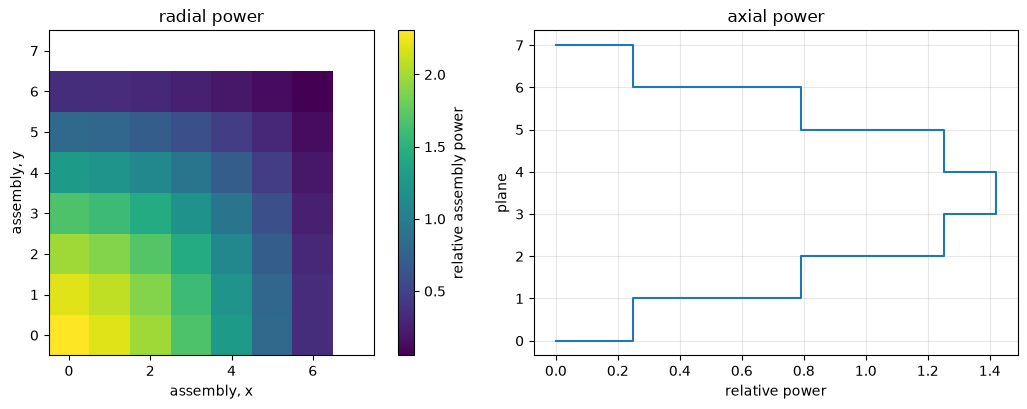

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
radial = core_result.radial_power()
masked = np.ma.masked_where(radial <= 0, radial)
im = axes[0].imshow(masked, origin="lower", cmap="viridis")
fig.colorbar(im, ax=axes[0], label="relative assembly power")
axes[0].set_title("radial power")
axes[0].set_xlabel("assembly, x")
axes[0].set_ylabel("assembly, y")

axial = core_result.axial_power()
axes[1].step(axial, np.arange(axial.size), where="mid")
axes[1].set_title("axial power")
axes[1].set_xlabel("relative power")
axes[1].set_ylabel("plane")
axes[1].grid(alpha=0.3)
fig.tight_layout()

## Where to go next

- `openndm.gc.add_adf_tallies` and `compute_adf` produce assembly
  discontinuity factors from the same lattice run; see
  `tests/validation/c2_assembly_adf.py`.
- `openndm.gc.BranchDriver` runs a parameterised sweep of OpenMC cases and
  assembles a branch-interpolated library. Notebook 4 shows the interpolation.
- `openndm.gc.critical_spectrum` performs the B1 or P1 buckling search on
  infinite-lattice data.
- `docs/user-guide.md` covers the solver API in full.